# Лекция 03. Функции <a class="anchor" id="0"></a>

## Оглавление:
* [03.01. Функции](#1)
* [03.02. Чтение и запись в файлы](#2)
* [03.03. Модули](#3)

## 03.01. Функции <a class="anchor" id="1"></a>
[Наверх](#0)

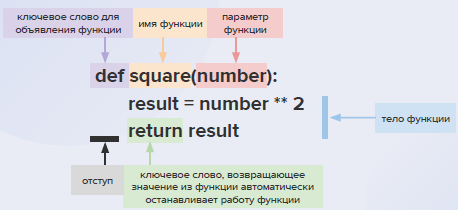

In [30]:
# создаем функцию
def square(number):
    result = number ** 2
    return result

print(square(10))
# Присваиваем переменной
my_square = square(10)
print(my_square)

100
100


In [36]:
# Функция help - вызов справки по функции
help(print)
# ?len # Альтернативный вариант

Help on built-in function print in module builtins:

print(...)
    print(value, ..., sep=' ', end='\n', file=sys.stdout, flush=False)
    
    Prints the values to a stream, or to sys.stdout by default.
    Optional keyword arguments:
    file:  a file-like object (stream); defaults to the current sys.stdout.
    sep:   string inserted between values, default a space.
    end:   string appended after the last value, default a newline.
    flush: whether to forcibly flush the stream.



In [40]:
# пишем docstring к своей функции
def square(number):
    """
    this is my function

    """
    result = number ** 2
    return result

help(square)

Help on function square in module __main__:

square(number)
    this is my function



In [41]:
# функция без параметров
def square_2():
    user_input = int(input('Введите число '))
    result = user_input ** 2
    return result
square_2()

Введите число 23


529

In [42]:
# функция с двумя параметрамим
def power(number, number_2):
    result = number ** number_2
    return result
power(4, 2)

16

In [43]:
# функция с параметром по умолчанию
def power(number, number_2=2):
    result = number ** number_2
    return result
power(4)

16

In [47]:
# если не указан return, функция всегда возвращает None!
def square_3(number):
    result = number ** 2
    print(result)
#     return None
#     return
square_3(5) # Выведет 25, т.к. сработает print в самой функции
print(square_3(5)) # Выведет 25 и None, т.к. сначала сработает print внутри функции, а потом результат из-за return

25
25
None


### Области видимости 
Области видимости:
* **Глобальная (global scope)**- Определена вне любой из функций и доступна любой функции в программе.
* **Локальная (local scope)** - Определяется внутри функции и доступна только из этой функции
* **Нелокальная (nonlocal scope)**

Если Python не может найти нужную переменную в локальной области видимости, то тогда (и только тогда) он будет искать ее в
области видимости уровня выше.

In [79]:
# Задаем глобальный контекст
number = 5
power = 3
# Эти же переменные на локальном уровне
def power_2():
    number = 6
    power = 2
    return number ** power

power_2()
print(number ** power)
# Результат - берем из глобального контекста

125


In [80]:
# Задаем глобальный контекст
number = 5
power = 3
# Задаем на локальном уровне только одну переменную
def power_2():
    number = 6
    return number ** power 
# Функция находит number и использует 6, потом ищет power, не находит и переходит на уровень выше, т.е. к глобальному уровню - 5

print(power_2()) # Вызов функции, следовательно 6^3
print(number ** power) # Вызов глобальных переменных, поэтому 5^3

216
125


In [81]:
# Задаем глобальный контекст
number = 5
power = 3
# На локальном уровне вообще на задаем переменных, поэтому переходим на глобальные
def power_2():
    return number ** power

power_2()

125

In [82]:
# Заведены локальные переменные
def power_2():
    number = 6
    power = 2
    some_number = 1
    return number ** power
# т.к. тут не обращаемся к функции, то используются глобальные переменные, а такой нет.
# При отсутствии переменной обращение идет только на уровень вверх, поэтому ошибка.
print(some_number)

NameError: name 'some_number' is not defined

Операторы global и nonlocal

In [83]:
# Операторы global и nonlocal - позваляют создать глобальную переменную в локальном контексте
# Объявим глобальную переменную
name = 'James'
# Функция с объявлением локальной переменную
def say_hi():
#     global name
    name = 'Oleg'
    print('Hello', name)
# Обращаемся к функции, поэтому локальная
say_hi()
# Выводим глобальную
print(name)

Hello Oleg
James


In [84]:
# Повторим предыдущее упражнение, только теперь добавим global name в функции

# Объявим глобальную переменную
name = 'James'
# Функция с объявлением локальной переменную
def say_hi():
    global name # Объявляем глобальную переменную
    name = 'Oleg'
    print('Hello', name)
# Обращаемся к функции, поэтому локальная
say_hi()
# Выводим глобальную, но она перезаписана внутри функции, поэтому одинаковый результат
print(name)

Hello Oleg
Oleg


In [85]:
# Функция say_hi задает переменную name и вызывает функцию  get_name
def say_hi():
    name = 'Oleg'
    # Функция запрашивает имя и больше ничего
    def get_name():
#         nonlocal name
        name = input('Введите имя')
        return name
    get_name()
    print('Hello', name)
# Результатом будет переменная объявленная ранее
say_hi()

Введите имяsdsd
Hello Oleg


In [86]:
# Повторим предыдущее упражнение, только теперь добавим nonlocal name в функции

# Функция say_hi задает переменную name и вызывает функцию  get_name
def say_hi():
    name = 'Oleg'
    # Функция запрашивает имя и больше ничего
    def get_name():
        nonlocal name # делает нелокальным переменную для области видимости выше
        name = input('Введите имя ')
        return name
    get_name()
    print('Hello', name)
# Результатом будет переменная, указанная в get_name
say_hi()

# Нужно понимать, как это работает, но лучше так не делать
# В целом практика менять логику интерпритатора и переопределять глобальные и локальные переменные
# Лучше декомпозировать код

Введите имя sds
Hello sds


### lambda-функции

In [87]:
# lambda-функции - используются для более краткой записи функций с одним (если в теле функции 1 строка, можно заменить на lambda)
func = lambda x, y: x + y 
print(func(1, 2))

3


In [88]:
nums = [1, 2, 3, 4, 5]

In [89]:
even_numbers = lambda x: x % 2 == 0
odd_even_numbers = lambda x: 'even' if x % 2 == 0 else 'odd'

In [90]:
for num in nums:
    print(odd_even_numbers(num))

odd
even
odd
even
odd


map Функция вызывает ко всем элемента объекта любые функции Не нужно делать циклы

In [93]:
# функция map
list(map(odd_even_numbers, nums))

['odd', 'even', 'odd', 'even', 'odd']

In [94]:
# Пример 2. 
def square(x):
    return x**2

In [95]:
# Выводим на экран каждый элемент полученный из map (возводим в квадрат каждое число)
for i in map(square, range(100, 105)):
    print(i)
    if i==10: break

10000
10201
10404
10609
10816


In [96]:
# Оффтоп - если нужно дополнительно показать индекс
# nums = [1, 2, 3, 4, 5]
# for num in nums:
#     print(num)

nums = [1, 2, 3, 4, 5]
for i, num in enumerate(nums):
    print(i,num)

0 1
1 2
2 3
3 4
4 5


In [97]:
list(map(square, range(100,105))) 

[10000, 10201, 10404, 10609, 10816]

### Если аргументы функции заранее неизвестны

args kwargs

In [98]:
# Создадим функцию, которая сворачивает все переменные в кортеж
def api_request(*params):
    date_start = params[0]
    date_end = params[1]
    print(params)
    print(date_start, date_end)

In [99]:
# Результат 1: Вводим 2 значения
api_request('2019-01-01', '2019-01-31')

('2019-01-01', '2019-01-31')
2019-01-01 2019-01-31


In [100]:
# Результат 2: Вводим 3 значения, выводит все равно 1 и 2. Если изменить в функции будет выводить и 3-ее
api_request('2019-01-01', '2019-01-31', 'ваыфафвыа')

('2019-01-01', '2019-01-31', 'ваыфафвыа')
2019-01-01 2019-01-31


In [101]:
# Кварги, работаемт также, но вместо кортежа создается словарь
def api_requets(**params):
    return params

In [102]:
api_requets(a=1, b=2, c=3)

{'a': 1, 'b': 2, 'c': 3}

In [103]:
def api_request(**params):
    date_start = params['date_start']
    date_end = params['date_end']
    
    print(date_start, date_end)

In [104]:
api_request(date_end='2019-01-31', date_start='2019-01-01')

2019-01-01 2019-01-31


## 03.02. Чтение и запись в файлы <a class="anchor" id="2"></a>
[Наверх](#0)

#### Вариант 1
Первый аргумент - путь к файлу: если открыть данный файл в jupyter, то можно не прописывать полный путь.
По умолчанию: где лежит исполняемый файл jupyter.exe
- **'r'** - открыть файл для чтения
- **'w'** - очистить файл и открыть для записи новых данных
- **'a'** - добавить строчки к концу файла

In [75]:
f = open('adult.csv', 'r')
for line in f:
    print(line)
    break
    
f.close() 

age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income



In [76]:
# конструкция with автоматически закрывает файл после работы с ним
# прочитать содержимое файла в список
with open('adult.csv', 'r') as f:
    content = f.readlines()

# content[:5]
content[1:6:2]

['25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K\n',
 '28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K\n',
 '18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K\n']

In [77]:
# прочитать большой файл построчно
with open('adult.csv') as f:
    for line in f:
        print(line)
        
        break

age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income



#### Попрактикуемся
Хотим классифицировать жителей в файле по возрастам:
* до 18 лет - children 
* 19-65 - young
* старше 65 - retiree

In [78]:
# подготовим файл для работы
i = 0
with open('adult.csv', 'r') as f:
    for line in f:
        print(line.strip().split(',')) # удаляем служебные символы и пробелы, разделяем по запятой
        
        i = i + 1
        if i > 5:
            break

['age', 'workclass', 'fnlwgt', 'education', 'educational-num', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
['25', 'Private', '226802', '11th', '7', 'Never-married', 'Machine-op-inspct', 'Own-child', 'Black', 'Male', '0', '0', '40', 'United-States', '<=50K']
['38', 'Private', '89814', 'HS-grad', '9', 'Married-civ-spouse', 'Farming-fishing', 'Husband', 'White', 'Male', '0', '0', '50', 'United-States', '<=50K']
['28', 'Local-gov', '336951', 'Assoc-acdm', '12', 'Married-civ-spouse', 'Protective-serv', 'Husband', 'White', 'Male', '0', '0', '40', 'United-States', '>50K']
['44', 'Private', '160323', 'Some-college', '10', 'Married-civ-spouse', 'Machine-op-inspct', 'Husband', 'Black', 'Male', '7688', '0', '40', 'United-States', '>50K']
['18', '?', '103497', 'Some-college', '10', 'Never-married', '?', 'Own-child', 'White', 'Female', '0', '0', '30', 'United-States', '<=50K']


Хотим классифицировать жителей в файле по возрастам:
* до 18 лет - children 
* 19-65 - young
* старше 65 - retiree

In [13]:
i = 0
#  открываем файл, распаковывыем: первый элемент в age, остальные во второй элемент
with open('adult.csv', 'r') as f:
    for line in f:
        age, *other_columns = line.strip().split(',')
        
        if i > 0:
            print(age)
        
        i += 1
        if i > 5:
            break

25
38
28
44
18


Добавим классификацию возрастов

In [14]:
i = 0
with open('adult.csv', 'r') as f:
    for line in f:
        age, *other_columns = line.strip().split(',')
#       Добавляем условия
        if i > 0:
            if int(age) <= 18:
                age_group = 'children'

            elif int(age) <= 60:
                age_group = 'young'

            else:
                age_group = 'retiree'
                
            print(age, age_group)
        
        i += 1
        if i > 10:
            break

25 young
38 young
28 young
44 young
18 children
34 young
29 young
63 retiree
24 young
55 young


Что тут нехорошо:
* сложно потестировать все случаи (в нашем цикле нужных случаев может и не оказаться)
* наш цикл стал довольно громоздким, а мы только начали
* эта классификация может потребоваться еще в 100500 местах кода
* данные могут быть кривыми и скрипт будет падать с ошибкой

Условия вычисления возрастной группы:
1. В строке 15 столбцов
2. Столбец с возрастом первый по счету
3. Возраст должен быть целым числом в адекватных пределах
4. Могут добавиться еще требования, о которых мы пока не знаем

In [15]:
def age_is_correct(age, lower_age=0, upper_age=120):
    """
    Проверка корректности возраста age по следующим правилам:
    1. Целое число
    2. В адекватных пределах
    
    Возвращает True или False. Пример
    age_is_correct(15)
    True
    
    age_is_correct(121)
    False
    
    age_is_correct(-5)
    False
    """
    
    if str.isnumeric(age):
        if lower_age <= int(age) <= upper_age:
            return True
    
    return False

age_is_correct('5')

True

In [16]:
def number_of_columns(line, separator=','):
    """Возвращает количество столбцов в строке line с разделителем separator"""
    
    return len(line.split(separator))

In [17]:
def line_is_correct(line):
    """
    Проверка строки на корректность. Проверяются условия:
    1. В строке 15 столбцов (пригодится с упражнения)
    2. Столбец с возрастом первый по счету
    3. Возраст должен быть целым числом в адекватных пределах
    """
    age = line.strip().split(',')[0]
    
    if number_of_columns(line) == 15:
        if age_is_correct(age):
            return True
    
    return False

In [ ]:
# Добавляем функции проверки в наш цикл

In [18]:
i = 0
with open('adult.csv', 'r') as f:
    for line in f:
        
        if line_is_correct(line):
            age, *other_columns = line.strip().split(',')
            if int(age) <= 18:
                age_group = 'children'

            elif int(age) <= 60:
                age_group = 'young'

            else:
                age_group = 'retiree'

            print(age, age_group)
        
        i += 1
        if i > 10:
            break

25 young
38 young
28 young
44 young
18 children
34 young
29 young
63 retiree
24 young
55 young


### Давайте вынесем классификацию возраста в отдельную функцию

In [19]:
def age_classification(age):
    """
    Возвращает возрастную категорию для возраста age (можно передать как строку).
    Классификация категорий:
        - до 18 лет - children 
        - 19-60 - young
        - старше 65 - retiree
    
    Пример
    age_classification('18')
    'children'
    
    age_classification(65)
    'retiree'
    """
    
    if int(age) <= 18:
        return 'children'
    if int(age) <= 65:
        return 'young'
    if int(age) > 65:
        return 'retiree'
    return 'boom'

In [20]:
age_classification(61)

'young'

In [21]:
def main():
    with open('adult.csv', 'r') as f:
        for line in f:
            if line_is_correct(line):
                age, *_ = line.strip().split(',')
                print(age, age_classification(age))

In [105]:
main()

25 young
38 young
28 young
44 young
18 children
34 young
29 young
63 young
24 young
55 young
65 young
36 young
26 young
58 young
48 young
43 young
20 young
43 young
37 young
40 young
34 young
34 young
72 retiree
25 young
25 young
45 young
22 young
23 young
54 young
32 young
46 young
56 young
24 young
23 young
26 young
65 young
36 young
22 young
17 children
20 young
65 young
44 young
36 young
29 young
20 young
28 young
39 young
54 young
52 young
56 young
18 children
39 young
21 young
22 young
38 young
21 young
63 young
34 young
42 young
33 young
30 young
39 young
26 young
33 young
47 young
41 young
41 young
19 young
46 young
43 young
55 young
46 young
30 young
21 young
46 young
17 children
41 young
69 retiree
50 young
20 young
45 young
23 young
24 young
44 young
31 young
43 young
20 young
55 young
24 young
41 young
59 young
49 young
33 young
59 young
34 young
20 young
25 young
49 young
59 young
20 young
51 young
33 young
22 young
58 young
52 young
36 young
41 young
28 young
19 young
18 

48 young
55 young
24 young
65 young
51 young
42 young
36 young
19 young
24 young
52 young
28 young
42 young
25 young
53 young
35 young
20 young
38 young
46 young
18 children
58 young
41 young
66 retiree
38 young
29 young
39 young
44 young
26 young
27 young
29 young
29 young
47 young
62 young
29 young
52 young
27 young
53 young
29 young
62 young
72 retiree
27 young
38 young
27 young
49 young
56 young
52 young
22 young
37 young
55 young
38 young
45 young
35 young
21 young
54 young
19 young
48 young
41 young
20 young
56 young
49 young
17 children
45 young
46 young
39 young
52 young
34 young
65 young
46 young
41 young
48 young
71 retiree
26 young
47 young
21 young
23 young
65 young
60 young
19 young
35 young
32 young
36 young
41 young
24 young
45 young
48 young
20 young
51 young
24 young
39 young
21 young
49 young
30 young
68 retiree
30 young
32 young
49 young
24 young
34 young
40 young
23 young
41 young
23 young
48 young
56 young
42 young
37 young
32 young
29 young
58 young
40 young
40 yo

19 young
18 children
35 young
21 young
20 young
49 young
34 young
37 young
36 young
44 young
39 young
36 young
53 young
34 young
24 young
40 young
47 young
19 young
18 children
32 young
21 young
27 young
58 young
29 young
34 young
45 young
43 young
63 young
26 young
42 young
21 young
36 young
44 young
18 children
69 retiree
40 young
37 young
39 young
57 young
28 young
23 young
20 young
46 young
44 young
67 retiree
31 young
24 young
54 young
28 young
30 young
42 young
17 children
32 young
25 young
49 young
35 young
32 young
17 children
61 young
56 young
50 young
32 young
41 young
41 young
19 young
18 children
25 young
21 young
34 young
31 young
36 young
19 young
35 young
18 children
39 young
30 young
59 young
28 young
47 young
27 young
56 young
18 children
76 retiree
56 young
40 young
39 young
24 young
23 young
36 young
55 young
23 young
39 young
32 young
32 young
17 children
29 young
54 young
37 young
67 retiree
48 young
17 children
41 young
43 young
29 young
43 young
46 young
42 young

55 young
30 young
39 young
23 young
28 young
42 young
35 young
39 young
29 young
21 young
35 young
42 young
28 young
57 young
59 young
50 young
37 young
20 young
46 young
28 young
32 young
20 young
38 young
36 young
30 young
35 young
30 young
56 young
30 young
64 young
21 young
17 children
49 young
37 young
52 young
55 young
24 young
23 young
31 young
17 children
50 young
33 young
24 young
37 young
31 young
77 retiree
21 young
18 children
25 young
57 young
25 young
62 young
35 young
26 young
47 young
25 young
33 young
28 young
42 young
50 young
61 young
50 young
23 young
27 young
51 young
37 young
25 young
38 young
60 young
66 retiree
74 retiree
37 young
26 young
39 young
19 young
35 young
43 young
31 young
35 young
30 young
22 young
36 young
19 young
36 young
29 young
30 young
31 young
27 young
44 young
17 children
36 young
43 young
46 young
24 young
42 young
55 young
61 young
20 young
60 young
24 young
33 young
67 retiree
34 young
34 young
38 young
50 young
45 young
55 young
18 child

36 young
33 young
52 young
51 young
44 young
19 young
49 young
17 children
20 young
53 young
25 young
48 young
27 young
21 young
29 young
47 young
48 young
38 young
19 young
37 young
37 young
39 young
35 young
33 young
56 young
23 young
25 young
47 young
32 young
24 young
32 young
41 young
32 young
37 young
39 young
66 retiree
18 children
23 young
44 young
45 young
42 young
40 young
20 young
26 young
25 young
40 young
54 young
33 young
56 young
27 young
31 young
61 young
22 young
32 young
29 young
34 young
56 young
35 young
25 young
22 young
19 young
35 young
35 young
48 young
52 young
39 young
32 young
27 young
34 young
31 young
47 young
37 young
47 young
47 young
45 young
51 young
24 young
59 young
27 young
33 young
55 young
62 young
37 young
45 young
25 young
34 young
50 young
29 young
32 young
48 young
34 young
50 young
38 young
52 young
41 young
31 young
31 young
50 young
23 young
52 young
33 young
32 young
48 young
40 young
22 young
55 young
58 young
43 young
34 young
19 young
50

...

29 young
43 young
37 young
56 young
58 young
54 young
45 young
29 young
26 young
43 young
33 young
45 young
25 young
25 young
69 retiree
37 young
20 young
39 young
17 children
27 young
26 young
55 young
39 young
41 young
34 young
51 young
67 retiree
40 young
58 young
23 young
45 young
51 young
43 young
25 young
36 young
58 young
33 young
60 young
24 young
45 young
49 young
19 young
34 young
42 young
25 young
73 retiree
59 young
28 young
19 young
31 young
58 young
21 young
47 young
30 young
41 young
59 young
43 young
48 young
44 young
44 young
24 young
28 young
50 young
33 young
23 young
30 young
46 young
21 young
52 young
26 young
27 young
28 young
50 young
28 young
61 young
32 young
30 young
51 young
40 young
36 young
28 young
49 young
61 young
41 young
55 young
36 young
21 young
57 young
49 young
59 young
41 young
59 young
20 young
42 young
41 young
45 young
36 young
42 young
25 young
45 young
58 young
39 young
34 young
22 young
44 young
53 young
22 young
27 young
60 young
46 young
5

19 young
67 retiree
41 young
29 young
28 young
25 young
21 young
24 young
48 young
46 young
35 young
35 young
50 young
22 young
45 young
62 young
39 young
33 young
22 young
50 young
25 young
44 young
26 young
31 young
56 young
49 young
49 young
46 young
33 young
25 young
40 young
72 retiree
32 young
44 young
48 young
17 children
50 young
61 young
22 young
17 children
49 young
26 young
19 young
17 children
38 young
34 young
51 young
48 young
63 young
19 young
73 retiree
51 young
38 young
54 young
41 young
65 young
36 young
42 young
38 young
20 young
37 young
35 young
51 young
23 young
27 young
19 young
37 young
29 young
33 young
60 young
22 young
22 young
60 young
35 young
45 young
30 young
43 young
32 young
35 young
32 young
61 young
40 young
20 young
42 young
21 young
21 young
26 young
36 young
24 young
47 young
51 young
65 young
61 young
67 retiree
49 young
63 young
58 young
61 young
36 young
19 young
29 young
43 young
60 young
21 young
22 young
33 young
36 young
37 young
35 young
17

41 young
39 young
31 young
38 young
43 young
27 young
42 young
46 young
20 young
42 young
69 retiree
47 young
49 young
20 young
52 young
33 young
18 children
55 young
61 young
61 young
39 young
30 young
61 young
36 young
34 young
53 young
38 young
46 young
27 young
32 young
60 young
23 young
29 young
22 young
25 young
29 young
90 retiree
37 young
32 young
18 children
35 young
50 young
54 young
43 young
28 young
51 young
31 young
69 retiree
57 young
71 retiree
28 young
28 young
25 young
49 young
52 young
23 young
32 young
31 young
30 young
24 young
45 young
30 young
52 young
42 young
49 young
20 young
25 young
41 young
55 young
31 young
25 young
32 young
29 young
37 young
52 young
19 young
21 young
43 young
39 young
40 young
54 young
35 young
34 young
35 young
57 young
26 young
55 young
51 young
35 young
31 young
17 children
38 young
39 young
29 young
39 young
42 young
46 young
73 retiree
47 young
28 young
27 young
38 young
19 young
60 young
24 young
52 young
36 young
26 young
28 young


38 young
42 young
47 young
44 young
28 young
51 young
51 young
49 young
62 young
31 young
29 young
23 young
40 young
66 retiree
17 children
37 young
69 retiree
23 young
38 young
37 young
38 young
38 young
37 young
37 young
23 young
17 children
48 young
17 children
55 young
35 young
68 retiree
35 young
53 young
43 young
36 young
24 young
45 young
34 young
56 young
36 young
22 young
19 young
33 young
48 young
20 young
64 young
47 young
20 young
44 young
45 young
45 young
45 young
27 young
41 young
20 young
54 young
17 children
50 young
31 young
49 young
44 young
49 young
28 young
43 young
33 young
35 young
17 children
25 young
41 young
30 young
48 young
61 young
41 young
36 young
24 young
27 young
18 children
20 young
18 children
23 young
43 young
38 young
36 young
28 young
47 young
51 young
35 young
38 young
47 young
26 young
31 young
46 young
49 young
19 young
45 young
46 young
70 retiree
19 young
46 young
20 young
17 children
43 young
19 young
37 young
51 young
40 young
24 young
31 yo

59 young
31 young
21 young
26 young
57 young
59 young
87 retiree
25 young
39 young
53 young
32 young
38 young
21 young
17 children
44 young
23 young
57 young
30 young
51 young
54 young
44 young
60 young
28 young
39 young
55 young
36 young
55 young
33 young
30 young
40 young
30 young
40 young
24 young
18 children
18 children
49 young
42 young
28 young
32 young
48 young
24 young
73 retiree
35 young
23 young
19 young
27 young
27 young
41 young
31 young
64 young
45 young
47 young
22 young
24 young
69 retiree
40 young
45 young
47 young
31 young
48 young
41 young
34 young
48 young
28 young
20 young
39 young
40 young
28 young
20 young
41 young
49 young
24 young
35 young
22 young
23 young
23 young
42 young
34 young
32 young
54 young
48 young
38 young
48 young
22 young
42 young
31 young
27 young
57 young
46 young
44 young
42 young
24 young
38 young
29 young
38 young
33 young
61 young
49 young
51 young
42 young
21 young
29 young
54 young
23 young
52 young
28 young
23 young
43 young
45 young
51 y

In [3]:
students_list = [
    {"name": "Василий", "surname": "Теркин", "sex": "мужчина", "program_exp": True, "grade": [8, 8, 9, 10, 9], "exam": 9},
    {"name": "Мария", "surname": "Павлова", "sex": "женщина", "program_exp": True, "grade": [7, 8, 9, 7, 9], "exam": 8},
    {"name": "Ирина", "surname": "Андреева", "sex": "женщина", "program_exp": False, "grade": [10, 9, 8, 10, 10], "exam": 10},
    {"name": "Татьяна", "surname": "Сидорова", "sex": "женщина", "program_exp": False, "grade": [7, 8, 8, 9, 8],"exam": 8},
    {"name": "Иван", "surname": "Васильев", "sex": "мужчина", "program_exp": True, "grade": [9, 8, 9, 6, 9], "exam": 10},
    {"name": "Роман", "surname": "Золотарев", "sex": "мужчина", "program_exp": False, "grade": [8, 9, 9, 6, 9], "exam": 10}
]

In [117]:
# Нужно определить среднюю оценку по группе

In [4]:
# Посчитаем среднюю оценку за экзамен
def get_average_stats(students):
    sum_exam = 0
    sum_hw = 0
    for student in students:
        sum_exam += student['exam']
        sum_hw += student['exam']
    print(f'Средняя оценка за экзамен по группе: {round(sum_exam/len(students),2)}')    

In [129]:
get_average_stats(students_list)

Средняя оценка за экзамен по группе: 9.17


In [5]:
# Посчитаем среднюю за домашку
def get_average_stats_02(students):
    sum_exam = 0
    sum_hw = 0
    for student in students:
        sum_exam += student['exam']
        sum_hw += sum(student['grade'])/len(student['grade'])
    print(f'Средняя оценка за экзамен по группе: {round(sum_exam/len(students),2)}')        
    print(f'Средняя оценка за домашку по группе: {round(sum_hw/len(students),2)}')    

In [131]:
get_average_stats_02(students_list)

Средняя оценка за экзамен по группе: 9.17
Средняя оценка за домашку по группе: 8.43


In [6]:
# Посчитаем среднюю оценку по полу
def get_average_stats_by_gender(students, gender = 'женщина'):
    sum_exam = 0
    sum_hw = 0
    students_counter = 0
    for student in students:
        if student['sex'] == gender:
            sum_exam += student['exam']
            sum_hw += sum(student['grade'])/len(student['grade'])
            students_counter += 1
    print(f'Средняя оценка за экзамен по группе: {round(sum_exam/students_counter,2)}')        
    print(f'Средняя оценка за домашку по группе: {round(sum_hw/students_counter,2)}')  

In [140]:
get_average_stats_by_gender (students_list)

Средняя оценка за экзамен по группе: 8.67
Средняя оценка за домашку по группе: 8.47


In [7]:
def main():
    while True:
        user_input = input()
        if user_input == '1':
            get_average_stats(students_list)
        elif user_input == '2':
            get_average_stats_02(students_list)
        elif user_input == '3':
            get_average_stats_by_gender(students_list,'мужчина')
        elif user_input == 'q':
            print('До свидания')
            break

In [8]:
main()

1
Средняя оценка за экзамен по группе: 9.17
2
Средняя оценка за экзамен по группе: 9.17
Средняя оценка за домашку по группе: 8.43
3
Средняя оценка за экзамен по группе: 9.67
Средняя оценка за домашку по группе: 8.4
q
До свидания


### 03.02. Модули <a class="anchor" id="3"></a>
[Наверх](#0)

In [23]:
import math

In [24]:
math.factorial(5)

120

In [25]:
import numpy

In [26]:
numpy.zeros(10)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [27]:
import numpy as np
np.zeros(10)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [28]:
from numpy import zeros
zeros(10)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [67]:
# попробовать импортировать собственную функцию (сохранить под расширением .py)

In [ ]:
# Домашняя работа:
# Задание 3. Рекурсивный вызов функции. Можно погуглить, найти варианты решения
# Задание 4. 